# Cleaning Summary: Treasury Bond Returns

In [1]:
import calc_treasury_bond_returns
import chartbook
import pandas as pd

# import polars as pl
import pull_he_kelly_manela

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

# Treasury Bond Returns Summary

By leveraging the TRACE dataset from openbondassetpricing.com, the FTSFR dataset ensures a robust foundation for analyzing treasury bond returns, adhering to established methodologies and incorporating comprehensive data cleaning procedures.

## Data Cleaning and Construction

The treasury bond returns dataset is constructed using the following cleaning and processing steps:

### 1. Bond Selection Criteria

* **CUSIP Filtering**:
  * Only include bonds with CUSIPs starting with '91' (indicating Treasury securities)
  * This ensures we're only analyzing genuine Treasury bonds

### 2. Return Processing

* **Return Conversion**:
  * Convert raw returns to decimal form by dividing by 100
  * This standardizes the return format for analysis

* **Return Filtering**:
  * Remove observations where returns exceed 50% (tr_return > 0.5)
  * This eliminates potential data errors or extreme outliers

### 3. Maturity Grouping

* **Maturity Bins**:
  * Create 10 maturity groups using 0.5-year intervals from 0 to 5 years
  * Bins: [0.0, 0.5, 1.0, ..., 5.0]
  * Each group represents a specific maturity range for analysis

* **Group Assignment**:
  * Assign each bond to a maturity group based on its time to maturity (tau)
  * Drop observations with missing maturity information
  * Convert group labels to integers for easier analysis

### 4. Portfolio Construction

* **Return Aggregation**:
  * Group bonds by date and maturity group
  * Calculate mean returns for each group
  * This creates a time series of portfolio returns for each maturity group

### 5. Data Quality Checks

* **Missing Value Handling**:
  * Remove observations with missing returns
  * Remove observations with missing maturity group assignments

* **Outlier Treatment**:
  * Extreme returns (>50%) are filtered out
  * This ensures the analysis focuses on normal market conditions

This cleaning process ensures a high-quality dataset for analyzing Treasury bond returns across different maturity groups, facilitating comparison with the Kelly-Manzello data.

In [2]:
hkm = pull_he_kelly_manela.load_he_kelly_manela_all(
    data_dir=DATA_DIR
)
treas_hkm = hkm.iloc[:, 34:44].copy()
treas_hkm["yyyymm"] = hkm["yyyymm"]
treas_hkm.head()
treas_hkm.tail()
treas_hkm.describe()
treas_hkm.isnull().sum()

US_bonds_01    25
US_bonds_02    25
US_bonds_03    25
US_bonds_04    25
US_bonds_05    25
US_bonds_06    25
US_bonds_07    25
US_bonds_08    25
US_bonds_09    25
US_bonds_10    25
yyyymm          0
dtype: int64

In [3]:
treas_bond_returns = calc_treasury_bond_returns.calc_returns(
    data_dir=DATA_DIR
)

In [4]:
treas_bond_returns.describe()

,DATE,1,2,3,4,5,6,7,8,9,10
count,671,671.000000,671.000000,671.000000,668.000000,668.000000,668.000000,671.000000,671.000000,668.000000,662.000000
mean,1997-12-30 04:13:14.038748288,0.003807,0.004238,0.004443,0.004461,0.004470,0.004833,0.005002,0.005147,0.005137,0.005117
min,1970-01-31 00:00:00,-0.000283,-0.008939,-0.025195,-0.032362,-0.046647,-0.052993,-0.052765,-0.060457,-0.058666,-0.059056
25%,1984-01-15 12:00:00,0.001242,0.000876,0.000460,0.000235,-0.000345,-0.000693,-0.001442,-0.002041,-0.002644,-0.003188
50%,1997-12-31 00:00:00,0.003784,0.003598,0.003527,0.003303,0.003468,0.003899,0.004080,0.004330,0.004448,0.004511
75%,2011-12-15 12:00:00,0.005313,0.006148,0.007147,0.007801,0.008764,0.010024,0.011169,0.012082,0.012843,0.013073
max,2025-11-30 00:00:00,0.023142,0.045551,0.064735,0.068330,0.091789,0.095415,0.086319,0.093149,0.093774,0.121050
std,NaN,0.003092,0.004609,0.006243,0.007455,0.008872,0.010435,0.011613,0.012947,0.013821,0.014949


### Comparing FTSFR with He Kelly Manela 

Treasury Bond Returns Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    671 non-null    datetime64[ns]
 1   1       671 non-null    float64       
 2   2       671 non-null    float64       
 3   3       671 non-null    float64       
 4   4       668 non-null    float64       
 5   5       668 non-null    float64       
 6   6       668 non-null    float64       
 7   7       671 non-null    float64       
 8   8       671 non-null    float64       
 9   9       668 non-null    float64       
 10  10      662 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 57.8 KB
None

Treasury Bond Returns Head:
        DATE         1         2         3         4         5         6  \
0 1970-01-31  0.008027  0.008752  0.006678  0.008800  0.010397  0.007652   
1 1970-02-28  0.008731  0.015935  0.016617  0.02

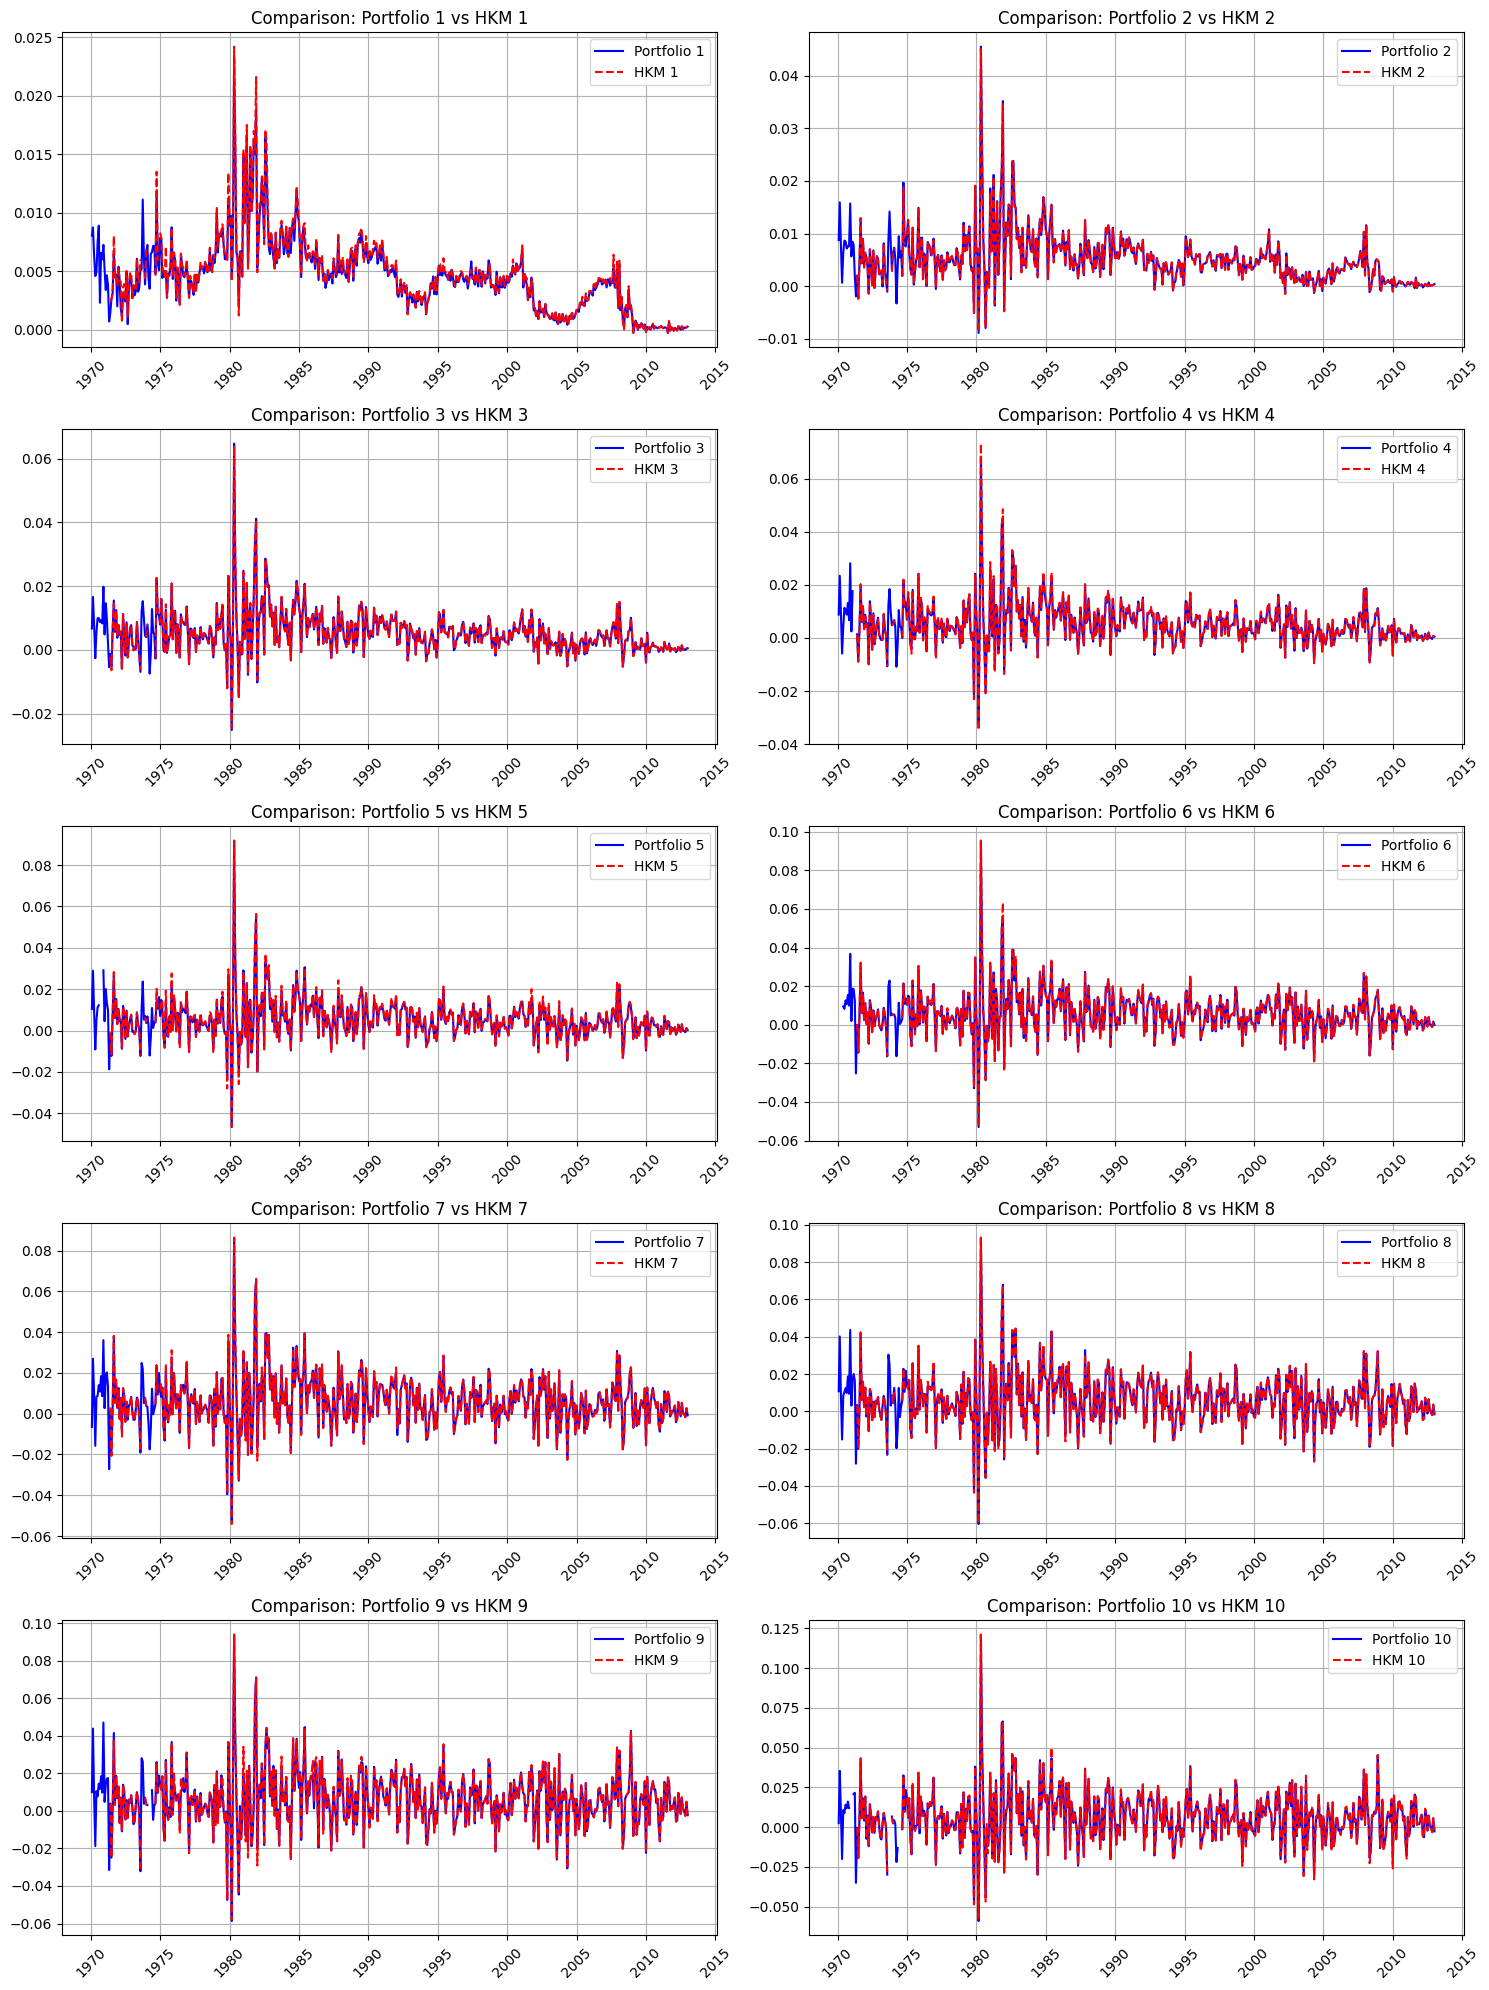


Correlations between corresponding columns:
Portfolio 1 vs HKM 1: 0.9939
Portfolio 2 vs HKM 2: 0.9996
Portfolio 3 vs HKM 3: 0.9995
Portfolio 4 vs HKM 4: 0.9983
Portfolio 5 vs HKM 5: 0.9960
Portfolio 6 vs HKM 6: 0.9987
Portfolio 7 vs HKM 7: 0.9982
Portfolio 8 vs HKM 8: 0.9988
Portfolio 9 vs HKM 9: 0.9953
Portfolio 10 vs HKM 10: 0.9975


In [5]:
# Print initial data info
print("Treasury Bond Returns Info:")
print(treas_bond_returns.info())
print("\nTreasury Bond Returns Head:")
print(treas_bond_returns.head())
print("\nTreasury Bond Returns Date Range:")
print(treas_bond_returns["DATE"].min(), "to", treas_bond_returns["DATE"].max())

print("\nHKM Treasury Bonds Info:")
print(treas_hkm.info())
print("\nHKM Treasury Bonds Head:")
print(treas_hkm.head())

# Convert treas_hkm dates to datetime
treas_hkm["date"] = pd.to_datetime(
    treas_hkm["yyyymm"].astype(int).astype(str), format="%Y%m"
) + pd.offsets.MonthEnd(0)

print("\nAfter date conversion - HKM Treasury Bonds Head:")
print(treas_hkm.head())
print("\nHKM Treasury Bonds Date Range:")
print(treas_hkm["date"].min(), "to", treas_hkm["date"].max())

# Convert treas_bond_returns DATE to datetime if it's not already
treas_bond_returns["DATE"] = pd.to_datetime(treas_bond_returns["DATE"])

print("\nAfter date conversion - Treasury Bond Returns Head:")
print(treas_bond_returns.head())
print("\nTreasury Bond Returns Date Range:")
print(treas_bond_returns["DATE"].min(), "to", treas_bond_returns["DATE"].max())

# Try the merge
merged_df = pd.merge(
    treas_bond_returns, treas_hkm, left_on="DATE", right_on="date", how="inner"
)

print("\nMerged DataFrame Shape:", merged_df.shape)
print("\nMerged DataFrame Head:")
print(merged_df.head())

# Create subplots for each pair of columns
import matplotlib.pyplot as plt

if not merged_df.empty:
    fig, axes = plt.subplots(5, 2, figsize=(15, 20))
    axes = axes.flatten()

    for i in range(10):
        col1 = str(i + 1)  # Column from treas_bond_returns
        if i == 9:
            col2 = "US_bonds_10"  # Column from treas_hkm
        else:
            col2 = f"US_bonds_0{i + 1}"  # Column from treas_hkm

        ax = axes[i]
        ax.plot(
            merged_df["DATE"], merged_df[col1], label=f"Portfolio {i + 1}", color="blue"
        )
        ax.plot(
            merged_df["DATE"],
            merged_df[col2],
            label=f"HKM {i + 1}",
            color="red",
            linestyle="--",
        )
        ax.set_title(f"Comparison: Portfolio {i + 1} vs HKM {i + 1}")
        ax.legend()
        ax.grid(True)

        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("\nNo data to plot - merged DataFrame is empty")

# Print correlation between corresponding columns
print("\nCorrelations between corresponding columns:")
for i in range(10):
    col1 = str(i + 1)
    if i == 9:
        col2 = "US_bonds_10"
    else:
        col2 = f"US_bonds_0{i + 1}"
    corr = merged_df[col1].corr(merged_df[col2])
    print(f"Portfolio {i + 1} vs HKM {i + 1}: {corr:.4f}")

---

### 📈 Comparison of Treasury Bond Portfolio Returns: FTSFR Portfolios vs. HKM Portfolios

The figure above compares the time-series returns of **Treasury bond portfolios**:

* **Portfolios 1–10** (in blue): Portfolios constructed by **FTSFR**, where Treasury bonds are sorted by **time remaining to maturity**, in 6-month intervals:

  * **Portfolio 1**: 0 to 6 months
  * **Portfolio 2**: 6 months to 1 year
  * **Portfolio 3**: 1 year to 1.5 years
  * **Portfolio 4**: 1.5 to 2 years
  * **Portfolio 5**: 2 to 2.5 years
  * **Portfolio 6**: 2.5 to 3 years
  * **Portfolio 7**: 3 to 3.5 years
  * **Portfolio 8**: 3.5 to 4 years
  * **Portfolio 9**: 4 to 4.5 years
  * **Portfolio 10**: 4.5 to 5 years

* **HKM Portfolios 1–10** (in red): Portfolios from **He, Kelly, and Manella (HKM)** using a similar 6-month maturity bucket structure for comparison.

---

### 🔍 Observations

* The returns between **FTSFR portfolios (blue)** and **HKM portfolios (red)** show **close alignment**, indicating a consistent term-structure pattern across both datasets.
* During periods of heightened volatility—such as the **2008 financial crisis** —portfolios with longer time to maturity generally exhibit greater return sensitivity, seen consistently in both series.
* Small return differences may result from:

  * Rounding errors due to different data sources and small values.
  * Missing values in the HKM data.

---

This comparison confirms that the **FTSFR replication tracks** the structure and return behavior of the HKM maturity-sorted Treasury portfolios.